In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from copy import copy

from pydrake.all import (
    DiagramBuilder,
    LinearQuadraticRegulator,
    Saturation,
    SceneGraph,
    Simulator,
    MeshcatVisualizer,
    LogVectorOutput,
    LeafSystem,
    wrap_to,
)

from pydrake.examples import (
    AcrobotGeometry,
    AcrobotInput,
    AcrobotPlant,
    AcrobotState,
    AcrobotSpongController,
)


def UprightState():
    state = AcrobotState()
    state.set_theta1(np.pi)
    state.set_theta2(0.0)
    state.set_theta1dot(0.0)
    state.set_theta2dot(0.0)
    return state


def angle_error(angle, target):
    """
    返回 angle 到 target 的最短角度误差，范围为 [-pi, pi]
    """
    return np.arctan2(np.sin(angle - target), np.cos(angle - target))


def wrap_to_0_2pi(angle):
    return np.mod(angle, 2.0 * np.pi)


def BalancingLQR(Q_diag=(50.0, 50.0, 5.0, 5.0), R_value=1.0):
    acrobot = AcrobotPlant()
    context = acrobot.CreateDefaultContext()

    input = AcrobotInput()
    input.set_tau(0.0)
    acrobot.get_input_port(0).FixValue(context, input)

    context.get_mutable_continuous_state_vector().SetFromVector(
        UprightState().CopyToVector()
    )

    Q = np.diag(Q_diag)
    R = [R_value]

    return LinearQuadraticRegulator(acrobot, context, Q, R)


class SpongSwingUpThenLQRController(LeafSystem):
    def __init__(
        self,
        Q_diag=(50.0, 50.0, 5.0, 5.0),
        R_value=1.0,
        theta1_threshold=0.6,
        theta2_threshold=0.6,
        velocity_threshold=8.0,
    ):
        LeafSystem.__init__(self)

        self.DeclareVectorInputPort("state", 4)
        self.DeclareVectorOutputPort("control", 1, self.DoCalcOutput)

        self.swingup = AcrobotSpongController()
        self.swingup_context = self.swingup.CreateDefaultContext()

        self.lqr = BalancingLQR(Q_diag=Q_diag, R_value=R_value)
        self.lqr_context = self.lqr.CreateDefaultContext()

        self.theta1_threshold = theta1_threshold
        self.theta2_threshold = theta2_threshold
        self.velocity_threshold = velocity_threshold

        self.has_switched = False

    def DoCalcOutput(self, context, output):
        x = self.get_input_port(0).Eval(context)

        x_wrapped = copy(x)
        x_wrapped[0] = wrap_to(x[0], 0.0, 2.0 * np.pi)
        x_wrapped[1] = wrap_to(x[1], -np.pi, np.pi)

        theta1_error = abs(angle_error(x_wrapped[0], np.pi))
        theta2_error = abs(angle_error(x_wrapped[1], 0.0))
        velocity_norm = np.linalg.norm(x_wrapped[2:4])

        near_upright = (
            theta1_error < self.theta1_threshold
            and theta2_error < self.theta2_threshold
            and velocity_norm < self.velocity_threshold
        )

        if near_upright:
            if not self.has_switched:
                print("Switch to LQR")
                self.has_switched = True

            self.lqr.get_input_port(0).FixValue(self.lqr_context, x_wrapped)
            u = self.lqr.get_output_port(0).Eval(self.lqr_context)
        else:
            self.swingup.get_input_port(0).FixValue(self.swingup_context, x)
            u = self.swingup.get_output_port(0).Eval(self.swingup_context)

        output.SetFromVector(u)

In [2]:
def find_first_sustained_time(condition, t, hold_time=1.0):
    """
    找到 condition 连续保持 hold_time 秒的首次时间。
    如果没有满足，返回 None。
    """
    condition = np.asarray(condition).astype(bool)

    for i in range(len(t)):
        if not condition[i]:
            continue

        j = i
        while j < len(t) and condition[j]:
            j += 1

        if t[j - 1] - t[i] >= hold_time:
            return t[i]

    return None


def evaluate_result(
    t,
    x,
    u,
    theta1_threshold=0.6,
    theta2_threshold=0.6,
    velocity_threshold=8.0,
    stable_theta1_threshold=0.10,
    stable_theta2_threshold=0.10,
    stable_velocity_threshold=0.50,
    hold_time=1.0,
):
    theta1_error = np.abs(angle_error(x[0, :], np.pi))
    theta2_error = np.abs(angle_error(x[1, :], 0.0))
    velocity_norm = np.sqrt(x[2, :] ** 2 + x[3, :] ** 2)

    switch_condition = (
        (theta1_error < theta1_threshold)
        & (theta2_error < theta2_threshold)
        & (velocity_norm < velocity_threshold)
    )

    stable_condition = (
        (theta1_error < stable_theta1_threshold)
        & (theta2_error < stable_theta2_threshold)
        & (velocity_norm < stable_velocity_threshold)
    )

    switch_time = find_first_sustained_time(
        switch_condition, t, hold_time=0.1
    )

    stable_time = find_first_sustained_time(
        stable_condition, t, hold_time=hold_time
    )

    final_theta1_error = theta1_error[-1]
    final_theta2_error = theta2_error[-1]
    final_velocity_norm = velocity_norm[-1]

    return {
        "switched_to_LQR": switch_time is not None,
        "switch_time_s": switch_time,
        "stable": stable_time is not None,
        "stable_time_s": stable_time,
        "final_theta1_error_rad": final_theta1_error,
        "final_theta2_error_rad": final_theta2_error,
        "final_velocity_norm_rad_s": final_velocity_norm,
        "max_abs_u_Nm": np.max(np.abs(u[0, :])),
        "rms_u_Nm": np.sqrt(np.mean(u[0, :] ** 2)),
    }


def simulate_and_log(
    Q_diag=(50.0, 50.0, 5.0, 5.0),
    R_value=1.0,
    u_max=5.0,
    theta1_threshold=0.6,
    theta2_threshold=0.6,
    velocity_threshold=8.0,
    sim_time=30.0,
    make_animation=False,
):
    builder = DiagramBuilder()

    acrobot = builder.AddSystem(AcrobotPlant())

    controller = builder.AddSystem(
        SpongSwingUpThenLQRController(
            Q_diag=Q_diag,
            R_value=R_value,
            theta1_threshold=theta1_threshold,
            theta2_threshold=theta2_threshold,
            velocity_threshold=velocity_threshold,
        )
    )

    saturation = builder.AddSystem(
        Saturation(min_value=[-u_max], max_value=[u_max])
    )

    builder.Connect(acrobot.get_output_port(0), controller.get_input_port(0))
    builder.Connect(controller.get_output_port(0), saturation.get_input_port(0))
    builder.Connect(saturation.get_output_port(0), acrobot.get_input_port(0))

    state_logger = LogVectorOutput(acrobot.get_output_port(0), builder)
    input_logger = LogVectorOutput(saturation.get_output_port(0), builder)

    if make_animation:
        scene_graph = builder.AddSystem(SceneGraph())
        AcrobotGeometry.AddToBuilder(builder, acrobot.get_output_port(0), scene_graph)

        meshcat.Delete()
        meshcat.Set2dRenderMode(xmin=-4, xmax=4, ymin=-4, ymax=4)
        MeshcatVisualizer.AddToBuilder(builder, scene_graph, meshcat)

    diagram = builder.Build()

    simulator = Simulator(diagram)
    context = simulator.get_mutable_context()
    simulator.set_target_realtime_rate(1.0 if make_animation else 0.0)

    context.SetContinuousState([0.1, 0.0, 0.0, 0.5])

    simulator.Initialize()
    simulator.AdvanceTo(sim_time)

    state_log = state_logger.FindLog(context)
    input_log = input_logger.FindLog(context)

    t = state_log.sample_times()
    x = state_log.data()
    u = input_log.data()

    metrics = evaluate_result(
        t,
        x,
        u,
        theta1_threshold=theta1_threshold,
        theta2_threshold=theta2_threshold,
        velocity_threshold=velocity_threshold,
    )

    return t, x, u, metrics

In [3]:
def plot_angle_response(t, x, title):
    """绘图"""
    theta1 = wrap_to_0_2pi(x[0, :])
    theta2 = x[1, :]

    plt.figure(figsize=(10, 5))

    plt.plot(t, theta1, linewidth=2, label=r"$\theta_1$ (Link 1 Absolute Angle)")
    plt.plot(t, theta2, linewidth=2, label=r"$\theta_2$ (Link 2 Relative Angle)")

    plt.axhline(
        np.pi,
        linestyle="--",
        linewidth=2,
        color="red",
        label=r"Upright Equilibrium ($\theta_1=\pi$)",
    )

    plt.axhline(
        0.0,
        linestyle=":",
        linewidth=1.5,
        color="gray",
        label=r"$\theta_2=0$",
    )

    plt.xlabel("Time (s)", fontsize=13)
    plt.ylabel("Joint Angle (rad)", fontsize=13)
    plt.title(title, fontsize=15)

    plt.yticks(
        [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi],
        [
            r"$-\pi$",
            r"$-\pi/2$",
            "0",
            r"$\pi/2$",
            r"$\pi$",
            r"$3\pi/2$",
            r"$2\pi$",
        ],
    )

    plt.ylim([-np.pi, 2 * np.pi])
    plt.grid(True)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


def plot_stable_time_bar_for_report(
    df,
    title="Stable Time Comparison",
    ylabel="Stable Time (s)",
    sim_time_limit=30.0,
    zoom_y_axis=False,
    ylim_margin=0.35
):
    plot_df = df.copy()

    labels = plot_df["case_name"].tolist()

    stable_times_raw = plot_df["stable_time_s"].tolist()
    stable_flags = plot_df["stable"].tolist()

    stable_times_plot = []
    value_labels = []

    for stable, value in zip(stable_flags, stable_times_raw):
        if stable and pd.notna(value):
            stable_times_plot.append(float(value))
            value_labels.append(f"{float(value):.2f}s")
        else:
            stable_times_plot.append(sim_time_limit)
            value_labels.append(f">{int(sim_time_limit)}s")

    x_pos = np.arange(len(labels))

    plt.figure(figsize=(10, 5))

    bars = plt.bar(
        x_pos,
        stable_times_plot,
        width=0.55,
        edgecolor="black",
        linewidth=1.0
    )

    for bar, label in zip(bars, value_labels):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.25,
            label,
            ha="center",
            va="bottom",
            fontsize=11
        )

    plt.axhline(
        sim_time_limit,
        linestyle="--",
        linewidth=1.5,
        color="red",
        label=f"Simulation limit = {int(sim_time_limit)} s"
    )

    if zoom_y_axis:
        valid_values = [
            float(v)
            for stable, v in zip(stable_flags, stable_times_raw)
            if stable and pd.notna(v)
        ]

        if len(valid_values) > 0:
            ymin = min(valid_values) - ylim_margin
            ymax = max(valid_values) + ylim_margin
            plt.ylim([ymin, ymax])
    else:
        plt.ylim([0, sim_time_limit + 4])

    plt.xticks(
        x_pos,
        labels,
        rotation=25,
        ha="right",
        fontsize=11
    )

    plt.ylabel(ylabel, fontsize=13)
    plt.title(title, fontsize=15)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 第一组：Q

In [4]:
def run_Q_ablation():
    cases = [
        {
            "case_name": "Baseline Q",
            "Q_diag": (50.0, 50.0, 5.0, 5.0),
            "description": "Baseline",
        },
        {
            "case_name": "High theta1 weight",
            "Q_diag": (200.0, 50.0, 5.0, 5.0),
            "description": "Increase theta1 penalty",
        },
        {
            "case_name": "High theta2 weight",
            "Q_diag": (50.0, 200.0, 5.0, 5.0),
            "description": "Increase theta2 penalty",
        },
        {
            "case_name": "High velocity weight",
            "Q_diag": (50.0, 50.0, 20.0, 20.0),
            "description": "Increase velocity penalty",
        },
    ]

    records = []
    trajectories = {}

    for case in cases:
        print(f"Running Q ablation: {case['case_name']}")

        t, x, u, metrics = simulate_and_log(
            Q_diag=case["Q_diag"],
            R_value=1.0,
            u_max=5.0,
            theta1_threshold=0.6,
            theta2_threshold=0.6,
            velocity_threshold=8.0,
            sim_time=30.0,
            make_animation=False,
        )

        record = {
            "experiment": "Q Ablation",
            "case_name": case["case_name"],
            "Q_diag": case["Q_diag"],
            "R": 1.0,
            "u_max": 5.0,
            "description": case["description"],
            **metrics,
        }

        records.append(record)
        trajectories[case["case_name"]] = (t, x, u)

    df = pd.DataFrame(records)
    display(df)

    plot_stable_time_bar_for_report(
        df,
        title="Fig. 5-5. Effect of LQR Q Matrix on Stable Time",
        zoom_y_axis=True
    )

    return df, trajectories

# 第二组:u 饱和限幅

In [5]:
def run_saturation_failure_cases():
    cases = [
        {"case_name": "u_max = 4", "u_max": 4.0},
        {"case_name": "u_max = 5", "u_max": 5.0},
        {"case_name": "u_max = 6", "u_max": 6.0},
        {"case_name": "u_max = 8", "u_max": 8.0},
        {"case_name": "u_max = 10", "u_max": 10.0},
        {"case_name": "u_max = 15", "u_max": 15.0},
    ]

    records = []
    trajectories = {}

    for case in cases:
        print(f"Running saturation case: {case['case_name']}")

        t, x, u, metrics = simulate_and_log(
            Q_diag=(50.0, 50.0, 5.0, 5.0),
            R_value=1.0,
            u_max=case["u_max"],
            theta1_threshold=0.6,
            theta2_threshold=0.6,
            velocity_threshold=8.0,
            sim_time=30.0,
            make_animation=False,
        )

        record = {
            "experiment": "Saturation Limit",
            "case_name": case["case_name"],
            "Q_diag": (50.0, 50.0, 5.0, 5.0),
            "R": 1.0,
            "u_max": case["u_max"],
            "description": "Input torque saturation comparison",
            **metrics,
        }

        records.append(record)
        trajectories[case["case_name"]] = (t, x, u)

    df = pd.DataFrame(records)
    display(df)

    plot_stable_time_bar_for_report(
        df,
        title="Fig. 5-6. Effect of Torque Saturation Limit on Stable Time",
        zoom_y_axis=False
    )

    return df, trajectories

# 第三组：切换准则

In [6]:
def run_switching_threshold_ablation():
    cases = [
        {
            "case_name": "Baseline switch",
            "theta1_threshold": 0.6,
            "theta2_threshold": 0.6,
            "velocity_threshold": 8.0,
            "description": "Baseline switching condition",
        },
        {
            "case_name": "Loose switch",
            "theta1_threshold": 0.8,
            "theta2_threshold": 0.8,
            "velocity_threshold": 10.0,
            "description": "Earlier switching, larger LQR region",
        },
        {
            "case_name": "Strict switch",
            "theta1_threshold": 0.4,
            "theta2_threshold": 0.4,
            "velocity_threshold": 6.0,
            "description": "Later switching, safer LQR region",
        },
        {
            "case_name": "Angle-only switch",
            "theta1_threshold": 0.6,
            "theta2_threshold": 0.6,
            "velocity_threshold": 999.0,
            "description": "Ignore velocity condition",
        },
    ]

    records = []
    trajectories = {}

    for case in cases:
        print(f"Running switching case: {case['case_name']}")

        t, x, u, metrics = simulate_and_log(
            Q_diag=(50.0, 50.0, 5.0, 5.0),
            R_value=1.0,
            u_max=5.0,
            theta1_threshold=case["theta1_threshold"],
            theta2_threshold=case["theta2_threshold"],
            velocity_threshold=case["velocity_threshold"],
            sim_time=30.0,
            make_animation=False,
        )

        record = {
            "experiment": "Switching Threshold",
            "case_name": case["case_name"],
            "theta1_threshold": case["theta1_threshold"],
            "theta2_threshold": case["theta2_threshold"],
            "velocity_threshold": case["velocity_threshold"],
            "Q_diag": (50.0, 50.0, 5.0, 5.0),
            "R": 1.0,
            "u_max": 5.0,
            "description": case["description"],
            **metrics,
        }

        records.append(record)
        trajectories[case["case_name"]] = (t, x, u)

    df = pd.DataFrame(records)
    display(df)

    plot_stable_time_bar_for_report(
        df,
        title="Fig. 5-7. Effect of Switching Criterion on Stable Time",
        zoom_y_axis=False
    )

    return df, trajectories

In [7]:
def make_report_table_q(q_df):
    table = q_df.copy()

    table["实验组"] = table["case_name"]
    table["参数"] = table["Q_diag"].astype(str)
    table["是否进入平衡态"] = table["stable"].map({True: "是", False: "否"})
    table["切换时间/s"] = table["switch_time_s"].map(lambda v: f"{v:.2f}" if pd.notna(v) else "未切换")
    table["收敛时间/s"] = table["stable_time_s"].map(lambda v: f"{v:.2f}" if pd.notna(v) else ">30")
    table["最大控制量/N·m"] = table["max_abs_u_Nm"].map(lambda v: f"{v:.2f}")
    table["最终角度误差/rad"] = table["final_theta1_error_rad"].map(lambda v: f"{v:.2e}")
    table["备注"] = table["description"]

    return table[
        [
            "实验组",
            "参数",
            "切换时间/s",
            "是否进入平衡态",
            "收敛时间/s",
            "最大控制量/N·m",
            "最终角度误差/rad",
            "备注",
        ]
    ]

Running Q ablation: Baseline Q
Switch to LQR
Running Q ablation: High theta1 weight
Switch to LQR
Running Q ablation: High theta2 weight
Switch to LQR
Running Q ablation: High velocity weight
Switch to LQR


,experiment,case_name,Q_diag,R,u_max,description,switched_to_LQR,switch_time_s,stable,stable_time_s,final_theta1_error_rad,final_theta2_error_rad,final_velocity_norm_rad_s,max_abs_u_Nm,rms_u_Nm
0,Q Ablation,Baseline Q,"(50.0, 50.0, 5.0, 5.0)",1.0,5.0,Baseline,True,6.176367,True,7.667394,8.636855e-15,1.738311e-14,1.606687e-13,5.0,3.622916
1,Q Ablation,High theta1 weight,"(200.0, 50.0, 5.0, 5.0)",1.0,5.0,Increase theta1 penalty,True,6.176367,True,7.619207,1.218957e-14,3.051904e-14,6.572257e-14,5.0,3.625693
2,Q Ablation,High theta2 weight,"(50.0, 200.0, 5.0, 5.0)",1.0,5.0,Increase theta2 penalty,True,6.176367,True,7.403282,1.041321e-14,2.735848e-14,6.045752e-15,5.0,3.631499
3,Q Ablation,High velocity weight,"(50.0, 50.0, 20.0, 20.0)",1.0,5.0,Increase velocity penalty,True,6.176367,True,8.095998,1.084189e-07,2.165951e-07,7.586334e-06,5.0,3.559014


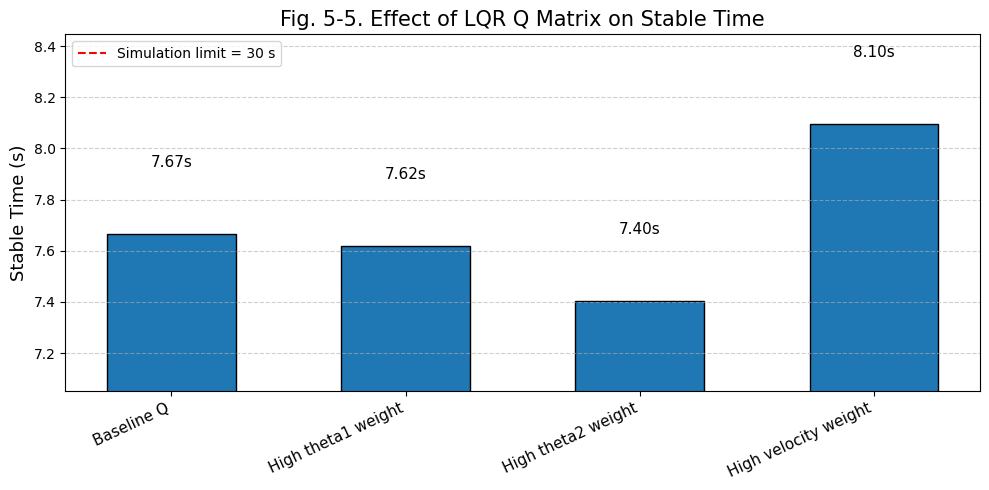

Running saturation case: u_max = 4
Switch to LQR
Running saturation case: u_max = 5
Switch to LQR
Running saturation case: u_max = 6
Switch to LQR
Running saturation case: u_max = 8
Switch to LQR
Running saturation case: u_max = 10
Switch to LQR
Running saturation case: u_max = 15
Switch to LQR


,experiment,case_name,Q_diag,R,u_max,description,switched_to_LQR,switch_time_s,stable,stable_time_s,final_theta1_error_rad,final_theta2_error_rad,final_velocity_norm_rad_s,max_abs_u_Nm,rms_u_Nm
0,Saturation Limit,u_max = 4,"(50.0, 50.0, 5.0, 5.0)",1.0,4.0,Input torque saturation comparison,False,NaN,False,NaN,9.488712e-02,1.616893e+00,6.428412e+00,4.0,3.375830
1,Saturation Limit,u_max = 5,"(50.0, 50.0, 5.0, 5.0)",1.0,5.0,Input torque saturation comparison,True,6.176367,True,7.667394,8.636855e-15,1.738311e-14,1.606687e-13,5.0,3.622916
2,Saturation Limit,u_max = 6,"(50.0, 50.0, 5.0, 5.0)",1.0,6.0,Input torque saturation comparison,True,11.089402,False,NaN,1.867673e+00,2.271767e+00,7.702108e+00,6.0,4.917649
3,Saturation Limit,u_max = 8,"(50.0, 50.0, 5.0, 5.0)",1.0,8.0,Input torque saturation comparison,True,27.255757,False,NaN,7.397960e-01,1.761170e+00,4.973067e+00,8.0,7.066627
4,Saturation Limit,u_max = 10,"(50.0, 50.0, 5.0, 5.0)",1.0,10.0,Input torque saturation comparison,True,6.688792,True,13.482033,2.664535e-15,7.366080e-15,4.868175e-14,10.0,5.898194
5,Saturation Limit,u_max = 15,"(50.0, 50.0, 5.0, 5.0)",1.0,15.0,Input torque saturation comparison,True,16.046652,True,16.902029,4.839212e-15,2.228500e-14,1.110312e-13,15.0,12.389068


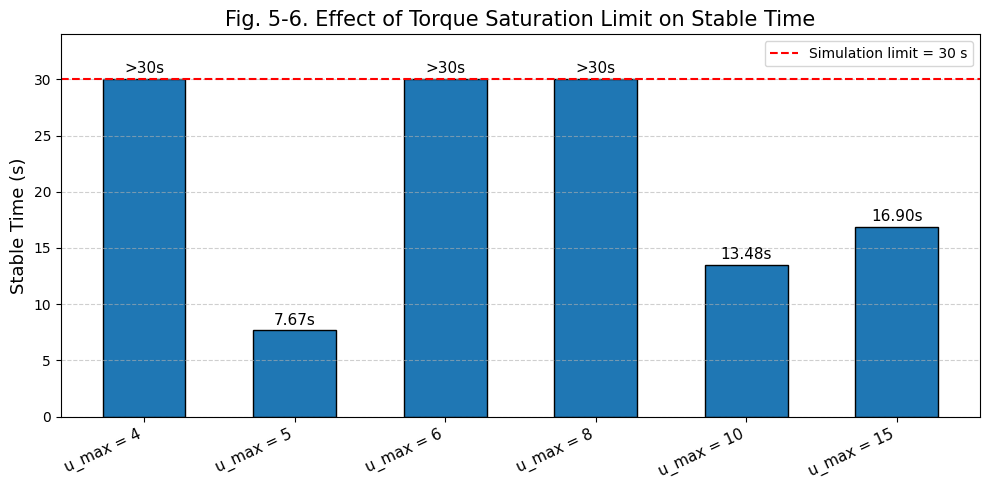

Running switching case: Baseline switch
Switch to LQR
Running switching case: Loose switch
Switch to LQR
Running switching case: Strict switch
Switch to LQR
Running switching case: Angle-only switch
Switch to LQR


,experiment,case_name,theta1_threshold,theta2_threshold,velocity_threshold,Q_diag,R,u_max,description,switched_to_LQR,switch_time_s,stable,stable_time_s,final_theta1_error_rad,final_theta2_error_rad,final_velocity_norm_rad_s,max_abs_u_Nm,rms_u_Nm
0,Switching Threshold,Baseline switch,0.6,0.6,8.0,"(50.0, 50.0, 5.0, 5.0)",1.0,5.0,Baseline switching condition,True,6.176367,True,7.667394,8.636855e-15,1.738311e-14,1.606687e-13,5.0,3.622916
1,Switching Threshold,Loose switch,0.8,0.8,10.0,"(50.0, 50.0, 5.0, 5.0)",1.0,5.0,"Earlier switching, larger LQR region",True,4.492950,False,NaN,7.708760e-01,1.886283e+00,8.652203e+00,5.0,3.992978
2,Switching Threshold,Strict switch,0.4,0.4,6.0,"(50.0, 50.0, 5.0, 5.0)",1.0,5.0,"Later switching, safer LQR region",True,6.515204,True,7.621677,2.449294e-16,2.593739e-16,1.054848e-13,5.0,3.620678
3,Switching Threshold,Angle-only switch,0.6,0.6,999.0,"(50.0, 50.0, 5.0, 5.0)",1.0,5.0,Ignore velocity condition,True,6.176367,True,7.667394,8.636855e-15,1.738311e-14,1.606687e-13,5.0,3.622916


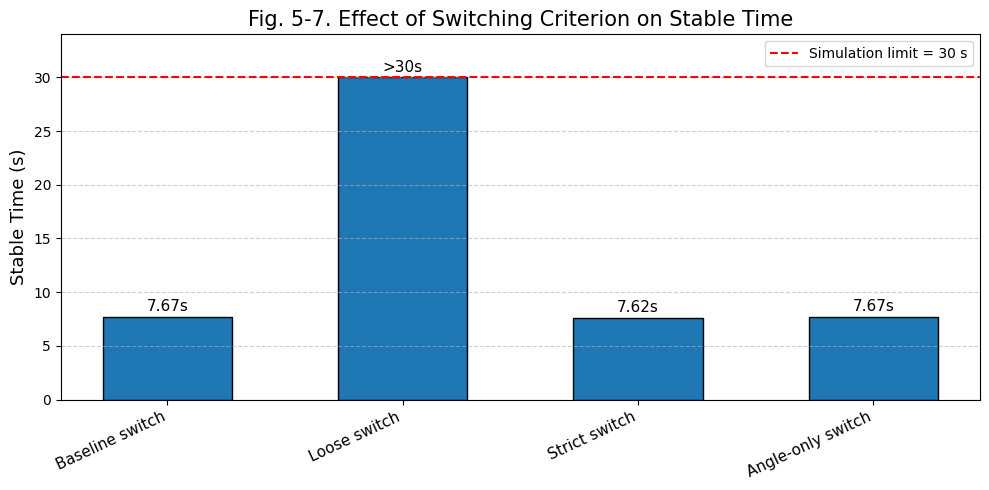

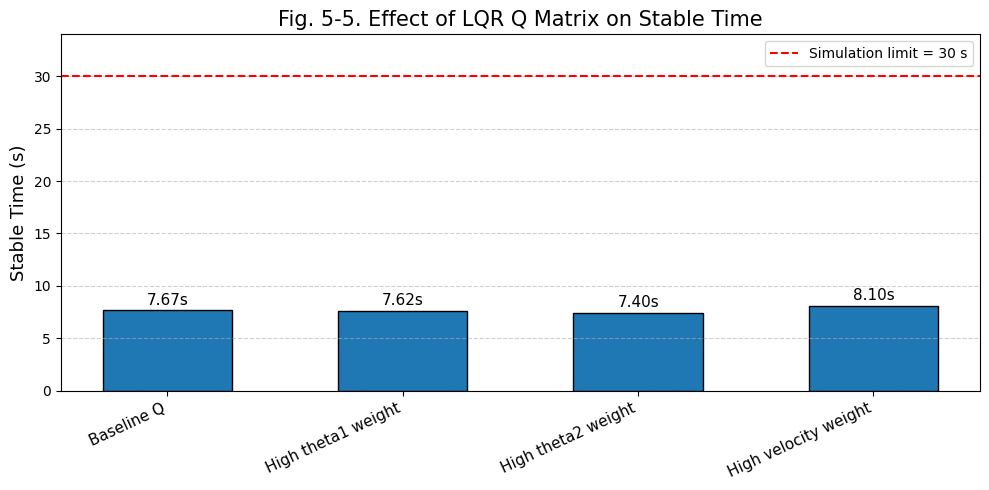

,实验组,参数,切换时间/s,是否进入平衡态,收敛时间/s,最大控制量/N·m,最终角度误差/rad,备注
0,Baseline Q,"(50.0, 50.0, 5.0, 5.0)",6.18,是,7.67,5.00,8.64e-15,Baseline
1,High theta1 weight,"(200.0, 50.0, 5.0, 5.0)",6.18,是,7.62,5.00,1.22e-14,Increase theta1 penalty
2,High theta2 weight,"(50.0, 200.0, 5.0, 5.0)",6.18,是,7.40,5.00,1.04e-14,Increase theta2 penalty
3,High velocity weight,"(50.0, 50.0, 20.0, 20.0)",6.18,是,8.10,5.00,1.08e-07,Increase velocity penalty


In [8]:
q_df, q_traj = run_Q_ablation()
sat_df, sat_traj = run_saturation_failure_cases()
switch_df, switch_traj = run_switching_threshold_ablation()


q_report_table = make_report_table_q(q_df)
display(q_report_table)